# 13 · Bayesian Tuning & Model Interpretability

This notebook demonstrates the two modeling additions made to the Life Expectancy
project and visualises their effect:

1. **Bayesian hyperparameter optimization** (`scikit-optimize` `BayesSearchCV`),
   wired into the time-aware modeling workflow via
   `life_expectancy.modeling.tuning`.
2. **Model interpretability** — SHAP and permutation feature importance via
   `life_expectancy.analysis.interpretability`.

Everything reuses the same panel, feature sets (A/B/C), and **time-aware split**
(last 3 years held out) as the rest of the modeling pipeline, so the numbers are
directly comparable to notebooks 06/09 and the `lifeexp train-*` commands.

> Requires the optional extras: `pip install -e ".[interpretability,advanced]"`.


In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

from life_expectancy.modeling.splits import make_time_split
from life_expectancy.modeling.train_eval import regression_metrics
from life_expectancy.modeling.tuning import (
    AVAILABLE_MODELS,
    build_tunable_pipeline,
    get_tunable_scale_numeric,
    tune_model,
)
from life_expectancy.analysis.interpretability import (
    permutation_importance_df,
    plot_permutation_bar,
    plot_shap_bar,
    shap_importance,
)


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "configs" / "default.yaml").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root(Path.cwd())
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
TABLE_DIR = PROJECT_ROOT / "reports" / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

TARGET, YEAR = "life_expectancy", "year"
FEATURE_SET = "B"
RANDOM_STATE = 42
N_ITER = 16   # Bayesian search evaluations per model
CV = 5
MODELS = ["ridge", "hgb", "rf"]

print("Project root:", PROJECT_ROOT)
print("Tunable models:", AVAILABLE_MODELS)

Project root: /Users/aleksia/Desktop/RND4IMPACT Projects/life-expectancy-analysis
Tunable models: ('ridge', 'lasso', 'elasticnet', 'hgb', 'rf', 'extra_trees', 'xgb', 'lgbm')


## 1 · Data and time-aware split

We load the model-ready frame and the persisted A/B/C feature sets, then build the
same temporal holdout used everywhere else: train on the earlier years, evaluate on
the most recent 3 years. This out-of-time test is the key reference for judging
whether tuning actually helps.

In [2]:
model_df = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "model_frame.csv")
feature_sets = json.loads(
    (TABLE_DIR / "feature_sets.json").read_text()
)["feature_sets"]
features = [c for c in feature_sets[FEATURE_SET] if c in model_df.columns]

work = model_df[list(dict.fromkeys([*features, TARGET, YEAR]))].copy()
x_train_all, x_test_all, y_train, y_test, split_info = make_time_split(
    work, target_col=TARGET, year_col=YEAR, test_years=3
)
x_train, x_test = x_train_all[features], x_test_all[features]

print(f"Feature set {FEATURE_SET}: {len(features)} features")
print(f"Train rows: {split_info.n_train} | Test rows: {split_info.n_test}")
print(f"Test years (temporal holdout): {split_info.extra['test_year_values']}")

Feature set B: 31 features
Train rows: 1812 | Test rows: 453
Test years (temporal holdout): [2013, 2014, 2015]


## 2 · Bayesian search vs. library defaults

For each model we compare two configurations on the **same temporal holdout**:

* **Default** — the tunable base estimator with library-default hyperparameters
  (the "before" baseline, equivalent to the grid/default workflow).
* **Bayesian-tuned** — the best estimator found by `BayesSearchCV` optimising
  5-fold cross-validated RMSE on the training years.

`tune_model` builds the pipeline and search space together, so the estimator and
its hyperparameter space can never drift out of sync.

In [3]:
records = []
searchers = {}

for name in MODELS:
    scale = get_tunable_scale_numeric(name)

    default_pipe = build_tunable_pipeline(
        name, x_train, random_state=RANDOM_STATE, scale_numeric=scale
    )
    default_pipe.fit(x_train, y_train)
    default_m = regression_metrics(y_test, default_pipe.predict(x_test))

    searcher = tune_model(
        name, x_train, y_train, n_iter=N_ITER, cv=CV, random_state=RANDOM_STATE
    )
    searchers[name] = searcher
    tuned_m = regression_metrics(y_test, searcher.best_estimator_.predict(x_test))

    records.append({
        "model": name,
        "default_test_rmse": round(default_m["rmse"], 4),
        "tuned_test_rmse": round(tuned_m["rmse"], 4),
        "rmse_improvement": round(default_m["rmse"] - tuned_m["rmse"], 4),
        "default_test_r2": round(default_m["r2"], 4),
        "tuned_test_r2": round(tuned_m["r2"], 4),
        "best_cv_rmse": round(-searcher.best_score_, 4),
    })

compare = pd.DataFrame(records)
compare.to_csv(TABLE_DIR / "week13_tuning_compare.csv", index=False)
compare

,model,default_test_rmse,tuned_test_rmse,rmse_improvement,default_test_r2,tuned_test_r2,best_cv_rmse
0,ridge,3.1357,3.1342,0.0015,0.8597,0.8598,3.3719
1,hgb,1.5905,1.6442,-0.0537,0.9639,0.9614,1.1822
2,rf,1.5973,1.6197,-0.0224,0.9636,0.9626,1.4552


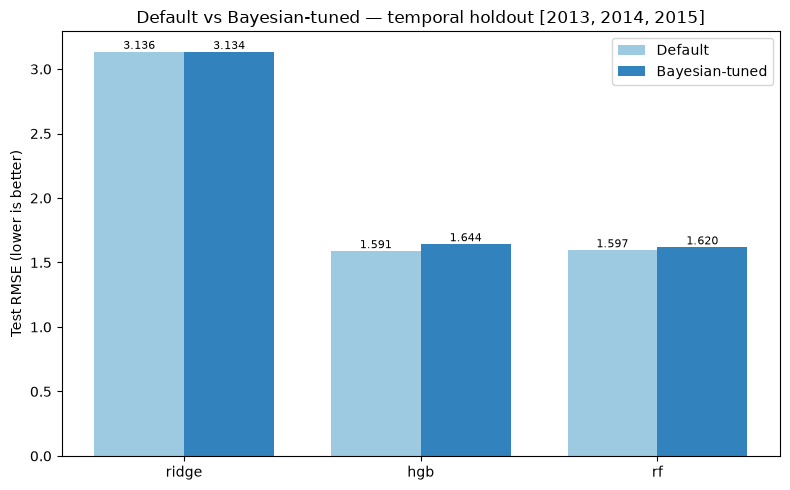

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
idx = np.arange(len(compare))
width = 0.38
ax.bar(idx - width / 2, compare["default_test_rmse"], width,
       label="Default", color="#9ecae1")
ax.bar(idx + width / 2, compare["tuned_test_rmse"], width,
       label="Bayesian-tuned", color="#3182bd")
ax.set_xticks(idx)
ax.set_xticklabels(compare["model"])
ax.set_ylabel("Test RMSE (lower is better)")
ax.set_title(
    f"Default vs Bayesian-tuned — temporal holdout {split_info.extra['test_year_values']}"
)
ax.legend()
for i, row in compare.iterrows():
    ax.text(i - width / 2, row["default_test_rmse"], f"{row['default_test_rmse']:.3f}",
            ha="center", va="bottom", fontsize=8)
    ax.text(i + width / 2, row["tuned_test_rmse"], f"{row['tuned_test_rmse']:.3f}",
            ha="center", va="bottom", fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "week13_tuning_default_vs_tuned_rmse.png", dpi=150)
plt.show()

## 3 · Search convergence

The search optimises **cross-validated** RMSE on the training years. The running-best
curve below shows how quickly `BayesSearchCV` improves the in-fold score. Note this
is the *CV* objective — it is not the same as the out-of-time test RMSE plotted above,
and the gap between them is exactly what we inspect in the findings.

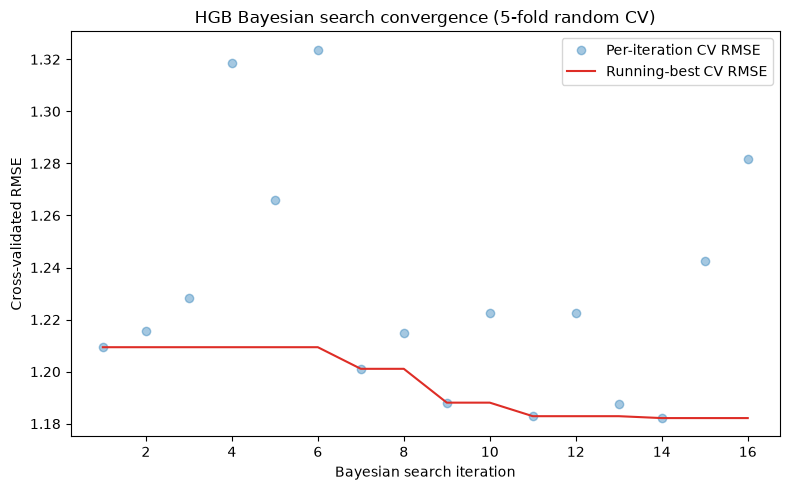

Best HGB params: {'model__l2_regularization': 0.8537613779084136, 'model__learning_rate': 0.14124669506880846, 'model__max_depth': 8, 'model__max_iter': 500, 'model__min_samples_leaf': 34}


In [5]:
hgb_cv = pd.DataFrame(searchers["hgb"].cv_results_)
per_iter_rmse = -hgb_cv["mean_test_score"].values
running_best_rmse = -np.maximum.accumulate(hgb_cv["mean_test_score"].values)
iterations = np.arange(1, len(per_iter_rmse) + 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(iterations, per_iter_rmse, "o", alpha=0.4, label="Per-iteration CV RMSE")
ax.plot(iterations, running_best_rmse, "-", color="#de2d26",
        label="Running-best CV RMSE")
ax.set_xlabel("Bayesian search iteration")
ax.set_ylabel("Cross-validated RMSE")
ax.set_title("HGB Bayesian search convergence (5-fold random CV)")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "week13_hgb_search_convergence.png", dpi=150)
plt.show()

print("Best HGB params:", dict(searchers["hgb"].best_params_))

## 4 · Interpretability — SHAP & permutation importance

We explain the **tuned HGB** model on the held-out test rows with two complementary
methods:

* **SHAP** (`TreeExplainer`) — average magnitude of each feature's contribution to
  individual predictions.
* **Permutation importance** — drop in test RMSE when a feature's values are
  shuffled.

SHAP operates on the transformed feature matrix (hence the imputer/encoder names);
permutation importance operates on the original input columns.

In [6]:
best_hgb = searchers["hgb"].best_estimator_

shap_df = shap_importance(best_hgb, x_test)
shap_df["feature"] = shap_df["feature"].str.replace("num__", "", regex=False)

perm_df = permutation_importance_df(
    best_hgb, x_test, y_test, n_repeats=10, random_state=RANDOM_STATE
)

shap_df.to_csv(TABLE_DIR / "week13_hgb_shap_importance.csv", index=False)
perm_df.to_csv(TABLE_DIR / "week13_hgb_permutation_importance.csv", index=False)

shap_df.head(10)

,feature,mean_abs_shap
0,hiv_aids,3.842321
1,income_composition_of_resources,2.565558
2,adult_mortality,1.309493
3,infant_deaths,0.475785
4,year,0.272955
5,bmi,0.258194
6,thinness_1_19_years,0.248921
7,schooling,0.237844
8,alcohol,0.224244
9,co2,0.211139


In [7]:
perm_df.head(10)

,feature,importance_mean,importance_std
0,income_composition_of_resources,3.211408,0.136473
1,hiv_aids,2.350406,0.208418
2,adult_mortality,1.805634,0.117397
3,infant_deaths,0.321198,0.032594
4,thinness_1_19_years,0.242846,0.028846
5,schooling,0.177297,0.024117
6,bmi,0.129199,0.018179
7,co2,0.115606,0.011740
8,health_expenditure_percent,0.111566,0.015278
9,alcohol,0.071275,0.019918


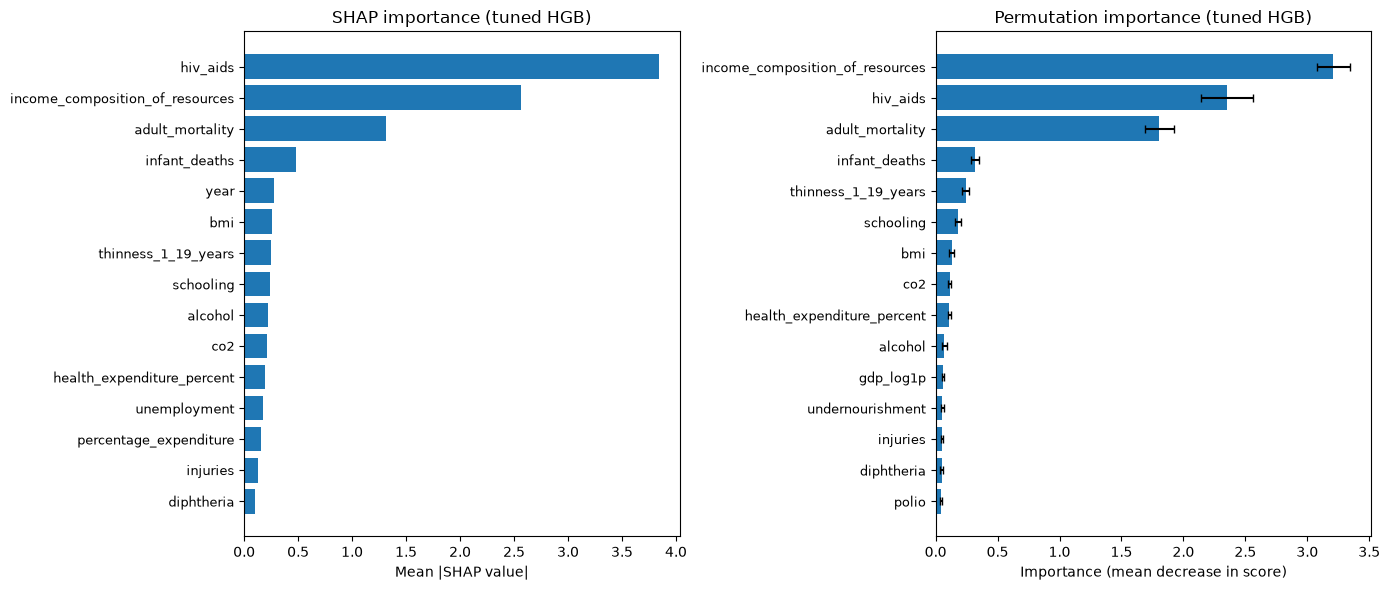

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_shap_bar(shap_df, ax=axes[0], n_features=15,
              title="SHAP importance (tuned HGB)")
plot_permutation_bar(perm_df, ax=axes[1], n_features=15,
                     title="Permutation importance (tuned HGB)")
fig.tight_layout()
fig.savefig(FIG_DIR / "week13_hgb_importance.png", dpi=150)
plt.show()

## 5 · Findings

**Interpretability (works as intended).** SHAP and permutation importance agree on
the dominant drivers of predicted life expectancy: `hiv_aids`,
`income_composition_of_resources`, and `adult_mortality` top both rankings (in
slightly different order), followed by `infant_deaths` and `schooling`.
The two methods are now reusable (`life_expectancy.analysis.interpretability`) and
exposed via `lifeexp interpret`.

**Tuning (integrated, but a cautionary result).** Bayesian search reliably drives the
*cross-validated* objective down (Section 3), yet on the **out-of-time** holdout the
tuned tree models do **not** beat their defaults — see the comparison table. The
defaults (well-regularised, moderate depth/iterations) already generalise well across
the year boundary, while the search — optimising a *random* 5-fold CV on the training
years — favours more expressive configurations that overfit the in-period folds.

**Takeaway / recommendation.** The value here is a reproducible, correctly-wired tuning
capability, plus the evidence that **random-CV tuning is the wrong objective for a
time-shifted target**. The natural next step is to run `BayesSearchCV` with a
time-series CV splitter so the search objective matches the temporal evaluation. The
linear `ridge` model, with a single regularisation parameter, is essentially unchanged
by tuning — consistent with the existing `RidgeCV` already finding a good alpha.
